# HW2 - Part 2 Template Attack
## Eyal Rechef - 213099468, Alon Abudraham - 324231992

### 1. Modifying the C code

Basically for our template attack we would want to change keys frequently, so we'll have to add a command to switch the key frequently,

For maximum flexibility, we'll just use one command which receives plaintext and a key (32 bytes) and returns the ciphertext (16 bytes), the C code:

```C
#include "aes-independant.h"
#include "hal.h"
#include "simpleserial.h"
#include <stdint.h>
#include <stdlib.h>

uint8_t get_pt(uint8_t *pt, uint8_t len)
{
	/*
	 * get_pt - does AES block encryption
	 *
	 * receives as input both key and a plaintext
	 * 'p' [16 bytes of plaintext] [16 bytes of key]
	 * 
	 * This function is given as a callback to the simpleserial interface
	 * will be called after receiving a command 'p' and a 32 byte input
	 */
	aes_indep_enc_pretrigger(pt);
	aes_indep_init();
	aes_indep_key(&pt[KEY_LENGTH]);

	trigger_high();
	aes_indep_enc(pt); /* encrypting the data block */
	trigger_low();

	aes_indep_enc_posttrigger(pt);

	simpleserial_put('r', KEY_LENGTH, pt);
	return 0x00;
}

int main(void)
{
	uint8_t secret_key[KEY_LENGTH] = {DEFAULT_KEY};

	platform_init();
	init_uart();
	trigger_setup();

	aes_indep_init();
	aes_indep_key(secret_key); // sets the key. size = 16 bytes

	simpleserial_init();
	simpleserial_addcmd('p', 2 * KEY_LENGTH, get_pt);
	while (1)
		simpleserial_get();
}
```


### Compiling our C code
Our C firmware for the STM target is found in this directory under the name `chipwhisperer_hw2_template.c`

First we will just compile the C firwmare for the target, there is a simple bash script here which calls the `makefile`:

In [1]:
%%bash
make PLATFORM=CWLITEARM SOURCE=chipwhisperer_hw2_template.c

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEARM with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (15:10.3-2021.07-4) 10.3.1 20210621 (release)
Copyright (C) 2020 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEARM 
.
Compiling:
-en     chipwhisperer_hw2_template.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal/hal.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal//stm32f3/stm32f3_hal.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal//stm32f3/stm32f3_hal_lowlevel.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware

## Simple imports and setting up the CW handler
We've added a simple object to make life easier for us: 

In [2]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, det
from tqdm.notebook import trange
from random import randbytes


class CWHandler:
    DEFAULT_FIRMWARE_HEX = "output-CWLITEARM.hex"
    TARGET_CMD_OPCODE = "p"
    AES_BLOCK_SIZE = 128
    AES_BLOCK_SIZE_BYTES = AES_BLOCK_SIZE // 8

    def __init__(self, adc_samples_num: int):
        """
        Initializes a CWHandler object
        Args:
            adc_samples_num (int): Number of sampmles within a
            trace outputed by the Chip Whisperer
        """
        self.scope = cw.scope()
        self.target = cw.target(self.scope, cw.targets.SimpleSerial)
        self.scope.default_setup()
        self.scope.adc.samples = adc_samples_num

    def __del__(self):
        self.scope.dis()
        self.target.dis()

    def program_target(self, hex_file: str):
        """
        Programs the STM32 target on the Chip Whisperer
        Args:
            hex_file (str): hex_file
        """
        cw.program_target(self.scope, cw.programmers.STM32FProgrammer, hex_file)

    def program_with_our_code(self):
        self.program_target(CWHandler.DEFAULT_FIRMWARE_HEX)

    def send_command(self, opcode: str, payload: bytes):
        self.target.flush()
        self.target.simpleserial_write(opcode, payload)
        ret = self.scope.capture()
        if ret:
            raise Exception("Error in capturing response from command")
        return ret

    def encrypt_and_capture_trace(self, plaintext: bytes, key: bytes) -> np.ndarray:
        self.target.flush()
        self.scope.arm()

        assert len(plaintext) == CWHandler.AES_BLOCK_SIZE_BYTES
        assert len(key) == CWHandler.AES_BLOCK_SIZE_BYTES

        self.target.simpleserial_write(CWHandler.TARGET_CMD_OPCODE, plaintext + key)

        ret = self.scope.capture()
        if ret:
            raise Exception("Error in capturing response from command")

        trace = self.scope.get_last_trace()
        response = self.target.simpleserial_read("r", CWHandler.AES_BLOCK_SIZE_BYTES)
        return response, trace

c:\Users\eyalr\ChipWhisperer\chipwhisperer\jupyter\.venv\Lib\site-packages\chipwhisperer\capture\trace\TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


Let's create a instance of our `CWHandler` - and program the target

In [3]:
ADC_SAMPLE_NUM = 5000

handler = CWHandler(ADC_SAMPLE_NUM)

handler.program_with_our_code()


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 2301687                   to 28348147                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

### 2. Developing the strategy

Before starting with our template attack, let's feel the water.

We'll run a simple test -

- First we'll create a function that receives a key, and outputs an averaged power trace of the AES operation with that key, together with a plaintext of 0s

- Next will want to see the impact of difference in each of the keys bytes, so will send a key that is 0s, apart from the byte we are currently checking, this byte will once be 0x00, and once be 0xFF

- We'll plot all the power traces to see if we are in the right direction - does it make any sense


  0%|          | 0/16 [00:00<?, ?it/s]

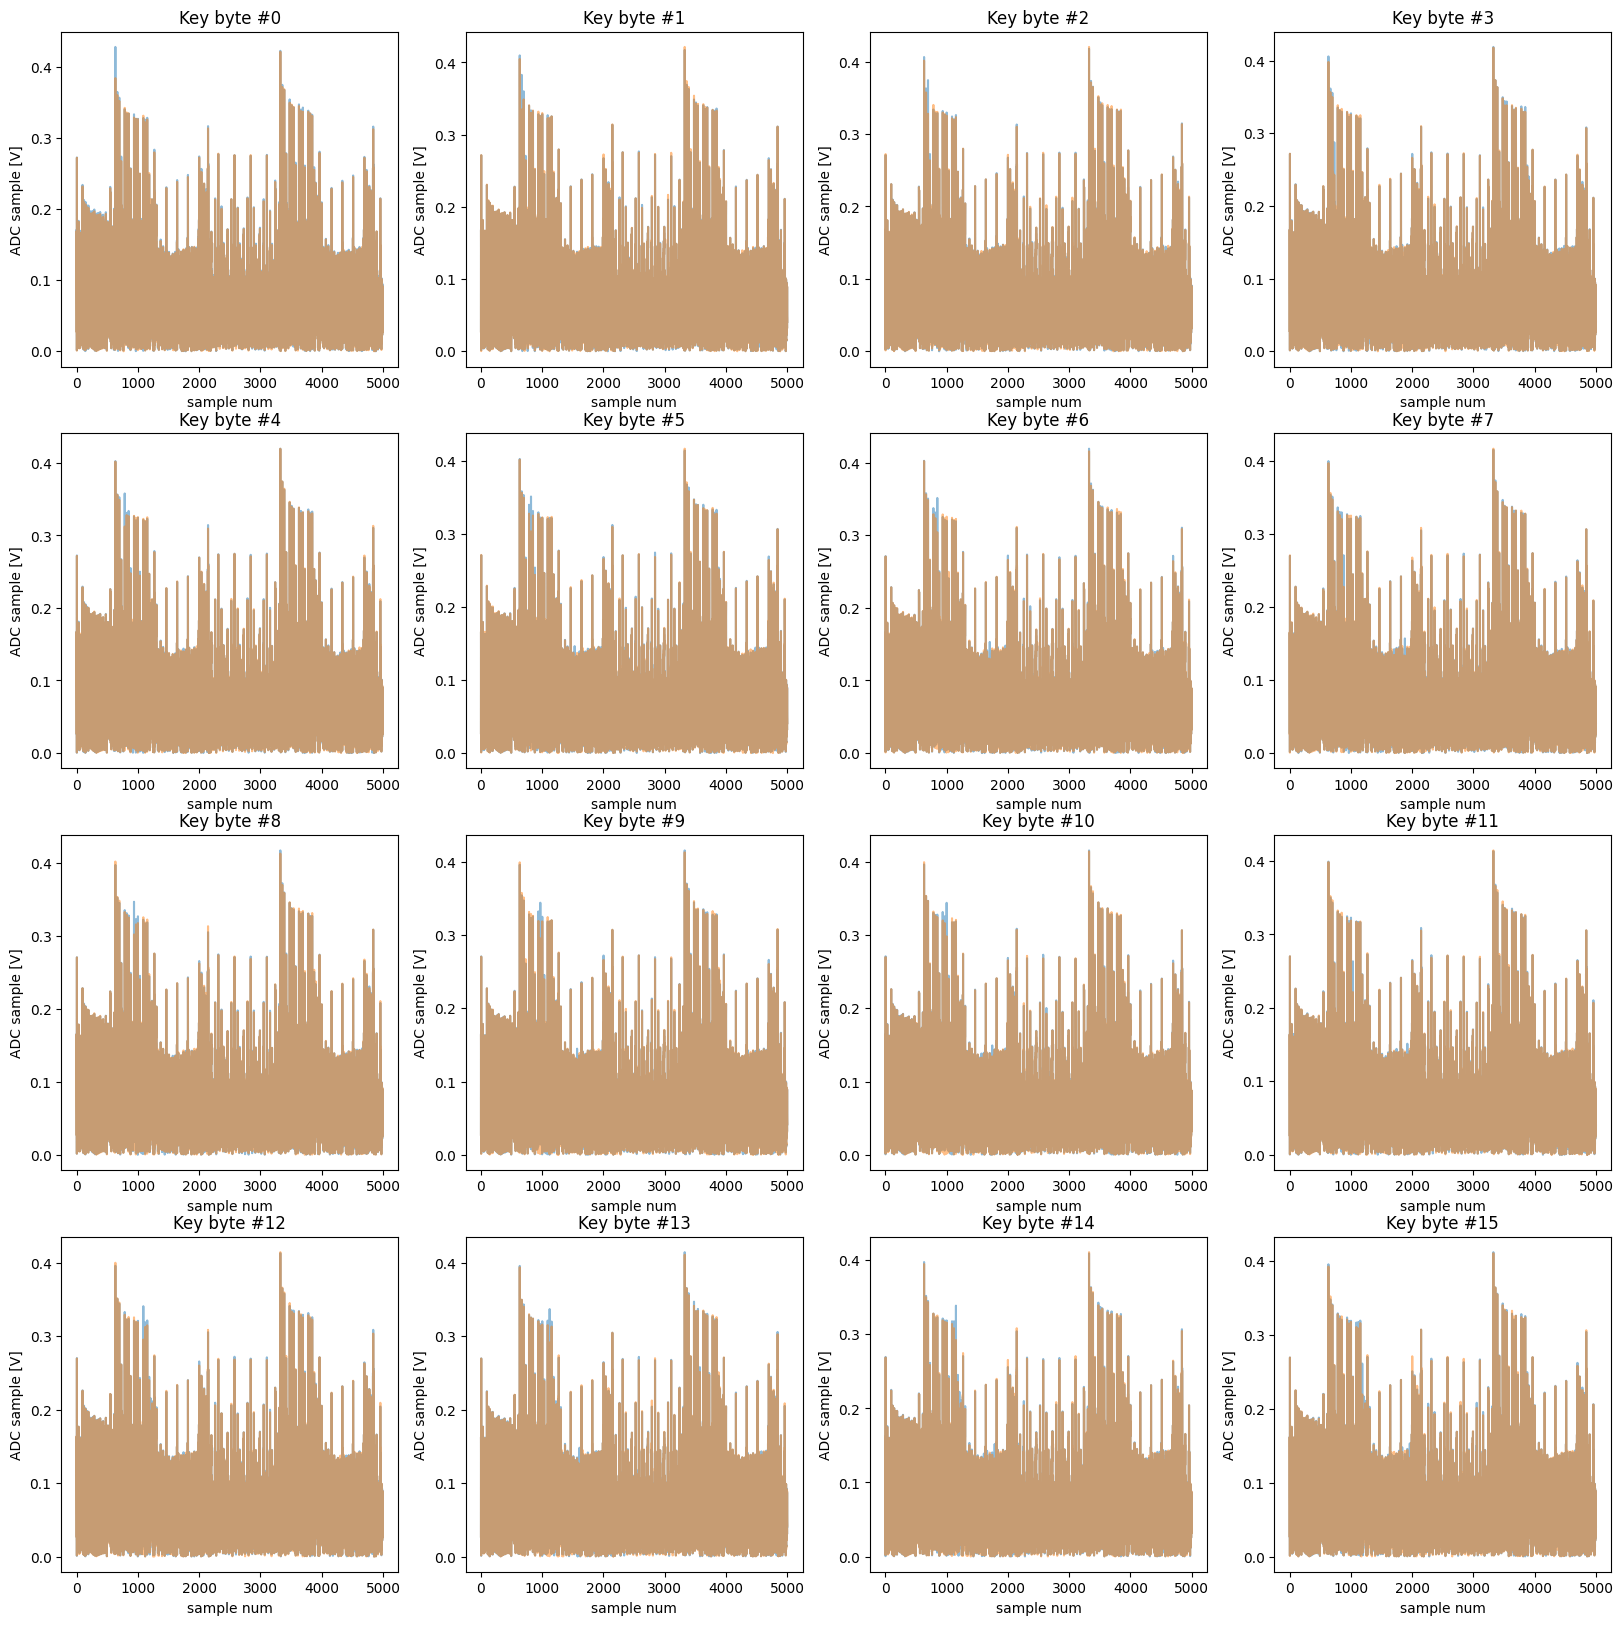

In [ ]:
def get_average_trace_for_random_key_with_fixed_index(
    byte_idx: int, byte_value: int, trace_num: int
) -> np.ndarray:
    accumulate_traces = np.zeros((ADC_SAMPLE_NUM))

    for _ in range(trace_num):
        key = bytearray(
            # bytes(CWHandler.AES_BLOCK_SIZE_BYTES)
            randbytes(CWHandler.AES_BLOCK_SIZE_BYTES)
        )
        key[byte_idx] = byte_value
        _, trace = handler.encrypt_and_capture_trace(
            # randbytes(CWHandler.AES_BLOCK_SIZE_BYTES), 
            bytes(CWHandler.AES_BLOCK_SIZE_BYTES),
            key
        )
        accumulate_traces += trace

    return np.abs(accumulate_traces / trace_num)




def sample_test(default_byte: int, changed_byte: int, sample_size: int):
    rows = int(np.sqrt(CWHandler.AES_BLOCK_SIZE_BYTES))
    _, axes = plt.subplots(rows, rows, figsize=(20, 20))

    for i in trange(CWHandler.AES_BLOCK_SIZE_BYTES):
        avg_trace_key_default = get_average_trace_for_random_key_with_fixed_index(
            i, default_byte, sample_size
        )
        avg_trace_key_changed = get_average_trace_for_random_key_with_fixed_index(
            i, changed_byte, sample_size
        )

        ax = axes[i // rows][i % rows]
        ax.plot(avg_trace_key_default, alpha=0.5)
        ax.plot(avg_trace_key_changed, alpha=0.5)
        ax.set_xlabel("sample num")
        ax.set_ylabel("ADC sample [V]")
        ax.set_title(f"Key byte #{i}")

    plt.show()

SAMPLE_SIZE = 20

sample_test(0xFF, 0x0, SAMPLE_SIZE)

The difference is very clear, with incrementing the key, we can see different power peaks changing between the case in which the byte is 0xFF (orange), and between the case the byte is 0x00 (blue).

Let's try to do something else, let's now try to change the default byte to 0xF, and each time change one byte to 0xFF, since the HW difference is now 4 and not 8, we would expect to see smaller changes in the peaks:

In [118]:
# sample_test(0x0F, 0xFF)

Well we indeed see smaller diffs.

And now, let's try value for the changed byte, with the same HW (say 0xF0), and now we would expect to see that the difference is minimal:

In [119]:
# sample_test(0x0F, 0xF0)

It seems as though there is no difference now, makes sense up until now.
Since we do not see any difference, it might be best to try few POIs since the first POI value looks the same for bytes with the same HW.

We'll now find our POIs mathematically, and not by "eye".


### 3. Capturing the power traces
For each byte, we'll sweep the 256 byte options (when the rest of the bytes are constant 0x0), and sample a large sample of traces for each option.

### 4. Identify clock cycles with the highest SNR for each key byte

Now we have lots of power traces - 
- For each byte index
    - For each option for this byte
        - Times the sample ratio (for averaging out noises)

Referring to the formula from class:

$$
M_{k, i} = \frac{1}{T_k}\sum_{j=1}^{T_k}t_{j,i}
$$

In our case $T_k=5$, $k$ is the byte sweeping from $0$ to $255$.

Then we'll calculate:

$$
D_i = \sum_{k_1, k_2}\left|M_{k_1, i} - M_{k_2, i}\right|
$$

Then our POI will be the point with the highest $D_i$.

Then when we'll have all $D$ - we can calculate the POIs by finding the highest point of $D_i$.
To find few POIs:

- Pick the highest point in $D_i$ and save this as the $n$-th POI
- Throw out the nearest $N$ points
- Repeat until enough POIs have been selected

We'll start with 3 POIs

In [ ]:
TK = 30
NUM_OF_POIS = 5
BYTE_OPTIONS = 2**8
MAX_SAMPLES = 5000

class PowerTraces:
    def __init__(self):
        self.power_traces = np.zeros(
            (CWHandler.AES_BLOCK_SIZE_BYTES, BYTE_OPTIONS, TK, MAX_SAMPLES)
        )
        self.poi_vector = [[] for _ in range(CWHandler.AES_BLOCK_SIZE_BYTES)]

    def collect_all_traces(self, trace_redundancy: int):
        for byte_idx in trange(CWHandler.AES_BLOCK_SIZE_BYTES):
            self.collect_power_traces_for_byte_idx(byte_idx, trace_redundancy)

    def collect_power_traces_for_byte_idx(self, byte_idx: int, sample_num: int):
        for byte in trange(BYTE_OPTIONS):
            for i in range(sample_num):
                self.power_traces[byte_idx][byte][i] = get_average_trace_for_random_key_with_fixed_index(byte_idx, byte, 1)
                

    def get_average_power_traces(self, byte_idx: int, byte_value: int):
        res = np.zeros((ADC_SAMPLE_NUM))
        for trace in self.power_traces[byte_idx][byte_value]:
            print(trace)
            res += trace
        return res / len(self.power_traces[byte_idx][byte_value])

    def get_d_for_byte_idx(self, byte_idx: int) -> np.ndarray:
        m_k = []
        for byte in range(BYTE_OPTIONS):
            m_k.append(self.get_average_power_traces(byte_idx, byte))

        d = np.zeros((ADC_SAMPLE_NUM))
        for k1 in range(BYTE_OPTIONS):
            for k2 in range(BYTE_OPTIONS):
                d += np.abs(m_k[k1] - m_k[k2])

        return d

    def extract_poi_from_d_vector(
        self, byte_idx: int, num_of_pois: int, min_poi_spacing: int
    ):
        d = self.get_d_for_byte_idx(byte_idx)
        for _ in range(num_of_pois):
            curr_poi = np.argmax(d)
            self.poi_vector[byte_idx].append(curr_poi)
            d[curr_poi - min_poi_spacing : curr_poi + min_poi_spacing] = 0


pt = PowerTraces()

# # 3. Collecting all the power traces
for byte_idx in range(1):
# # for byte_idx in trange(CWHandler.AES_BLOCK_SIZE_BYTES):
    pt.collect_power_traces_for_byte_idx(byte_idx, TK)

np.save('samples.npy', pt.power_traces)
# pt.power_traces = np.load('samples.npy')

  0%|          | 0/256 [00:00<?, ?it/s]

In [ ]:
NUM_OF_POIS = 15
MIN_POI_SPACING = 10

pt.poi_vector = [[] for _ in range(CWHandler.AES_BLOCK_SIZE_BYTES)]


# Get all d_i vector
# for idx in range(CWHandler.AES_BLOCK_SIZE_BYTES):
for idx in range(1):
    pt.extract_poi_from_d_vector(2, NUM_OF_POIS, MIN_POI_SPACING)
    print(f"Our POI for key byte #{idx} is {pt.poi_vector[idx]}")

[0.03027344 0.16503906 0.12792969 ... 0.08984375 0.05566406 0.04101562]
[0.02832031 0.16601562 0.12597656 ... 0.08886719 0.05371094 0.04003906]
[0.02929688 0.16113281 0.12695312 ... 0.09570312 0.05761719 0.04394531]
[0.02929688 0.16503906 0.12695312 ... 0.08886719 0.05273438 0.0390625 ]
[0.03027344 0.16015625 0.12402344 ... 0.09082031 0.05761719 0.04199219]
[0.03027344 0.16601562 0.125      ... 0.08691406 0.05761719 0.04101562]
[0.02832031 0.16796875 0.125      ... 0.08203125 0.05078125 0.03710938]
[0.02734375 0.16601562 0.125      ... 0.09375    0.06152344 0.046875  ]
[0.0234375  0.16601562 0.13085938 ... 0.08496094 0.04882812 0.03808594]
[0.02441406 0.16601562 0.13085938 ... 0.08789062 0.05371094 0.03808594]
[0.02734375 0.16210938 0.12792969 ... 0.08496094 0.05175781 0.03710938]
[0.02636719 0.16601562 0.12988281 ... 0.08789062 0.05371094 0.03808594]
[0.03125    0.1640625  0.125      ... 0.08691406 0.05175781 0.04101562]
[0.02636719 0.16503906 0.12597656 ... 0.0859375  0.04980469 0.04

Now we have the POIs for each key byte (5 for each).

### 5. Characterize the leakage by estimating PDFs for different key values
For each key byte, we'll generate a probability density function (PDF) for the leakage at its POIs.

1. Grouping by Operation
    - We already have all the power traces that fall under "operation $k$", these are just the power traces taken for a specific byte value
    - Then we extract the POIs from these to create a Data Matrix for operation $k$: $\{ t_{j,s_i} \}_{j=1\dots T_k,i=1\dots I}$ where $T_k$ is the trace redundancy and $I$ is the number of POIs.

2. Mean Vector Estimation
    - We'll compute average leakage at each POI for operation $k$ - $\mu_i = \sum_{j=1}^{T_k}t_{j,s_i}$
    - Builds the mean vector - $\mu_k = [\mu_1\ \mu_2\ \dots\ \mu_I]^T$

3. Variance & Covariance Estimation
    - Now we can calculate variance for each POI - $v_i=\frac{1}{T_k}\sum_{j=1}^{T_k}(t_{j,s_i}-\mu_i)^2$
    - And the covariance for every pair of POIs - $c_{i,i^*}=\frac{1}{T_k}\sum_{j=1}^{T_k}(t_{j,s_i}-\mu_i)(t_{j,s_{i^*}}-\mu_{i^*})$
    - Put these into a covariance matrix: $\Sigma_k = 
\begin{bmatrix}
v_1 & c_{1,2} & c_{1,3} & \cdots \\
c_{2,1} & v_2 & c_{2,3} & \cdots \\
c_{3,1} & c_{3,2} & v_3 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{bmatrix}$

4. Template Definition
    - Now we can create a template (PDF) for each operation $k$, and a vector $x$ of power samples in its POIs:

    $$
    f_k(x)=\frac{1}{\sqrt{(2\pi)^I\left|\Sigma_k\right|}}e^{-\frac{1}{2}(x-\mu_k)^T(\Sigma_k)^{-1}(x-\mu_k)}
    $$

In [ ]:
EPSILON = 1e-6  # For allowing inversion and aviod division by 0


class Template:
    def __init__(self, pt: PowerTraces):
        self.pt = pt
        self.t_j_si = np.zeros(
            (CWHandler.AES_BLOCK_SIZE_BYTES, BYTE_OPTIONS, TK, NUM_OF_POIS)
        )
        self.mu_k = np.zeros(
            (CWHandler.AES_BLOCK_SIZE_BYTES, BYTE_OPTIONS, NUM_OF_POIS)
        )
        self.cov_ii = np.zeros(
            (CWHandler.AES_BLOCK_SIZE_BYTES, BYTE_OPTIONS, NUM_OF_POIS, NUM_OF_POIS)
        )
        self.cov_ii_inv = np.zeros(
            (CWHandler.AES_BLOCK_SIZE_BYTES, BYTE_OPTIONS, NUM_OF_POIS, NUM_OF_POIS)
        )

    def extract_t_j_si(self, byte_idx: int):
        for byte in range(BYTE_OPTIONS):
            for i, trace in enumerate(self.pt.power_traces[byte_idx][byte]):
                self.t_j_si[byte_idx][byte][i] = trace[self.pt.poi_vector[byte_idx]]

    def calculate_mu_k(self, byte_idx: int):
        for byte in range(BYTE_OPTIONS):
            self.mu_k[byte_idx][byte] = sum(self.t_j_si[byte_idx][byte]) / TK

    def calculate_cov_ii(self, byte_idx: int):
        for byte in range(BYTE_OPTIONS):
            for i in range(NUM_OF_POIS):
                for i_star in range(NUM_OF_POIS):
                    res = 0
                    for j in range(TK):
                        res += (
                            self.t_j_si[byte_idx][byte][j][i]
                            - self.mu_k[byte_idx][byte][i]
                        ) * (
                            self.t_j_si[byte_idx][byte][j][i_star]
                            - self.mu_k[byte_idx][byte][i_star]
                        )
                    res /= TK
                    self.cov_ii[byte_idx][byte][i][i_star] = res
            self.cov_ii[byte_idx][byte] += EPSILON * np.eye(NUM_OF_POIS)
            self.cov_ii_inv[byte_idx][byte] = inv(self.cov_ii[byte_idx][byte])

    def get_template_parameters(self, byte_idx: int):
        self.extract_t_j_si(byte_idx)
        self.calculate_mu_k(byte_idx)
        self.calculate_cov_ii(byte_idx)

    def get_all_templates(self):
        for byte_idx in range(CWHandler.AES_BLOCK_SIZE_BYTES):
            self.get_all_templates(byte_idx)

    def get_pdf_value(self, byte_idx: int, byte_value: int, x: np.ndarray):
        """
        calculates f_k(x), f_k is the PDF for the template of byte_value in byte_idx
        """
        mu_k = self.mu_k[byte_idx][byte_value]
        sigma_k = self.cov_ii[byte_idx][byte_value]
        sigma_k_inv = self.cov_ii_inv[byte_idx][byte_value]

        normalized_x = x - mu_k
        res = np.exp(-0.5 * normalized_x @ sigma_k_inv @ normalized_x.T)
        res /= np.sqrt(((2 * np.pi) ** NUM_OF_POIS) * det(sigma_k))
        return res


template = Template(pt)
template.get_template_parameters(2)


def hamming_weight(x: int) -> int:
    res = 0
    while x != 0:
        res += x & 1
        x >>= 1
    return res


succ_count = 0
hw_succ_count = 0
for exp_key in trange(BYTE_OPTIONS):
    traces = []

    for i in range(5):
        traces.append(get_average_trace_for_random_key_with_fixed_index(0, exp_key, 5)[pt.poi_vector[0]])

    res = np.zeros((BYTE_OPTIONS))
    for byte in range(BYTE_OPTIONS):
        res[byte] = sum(
            [np.log(template.get_pdf_value(0, byte, trace)) for trace in traces]
        )

    # print(f"expected {hex(exp_key)}")
    meas = np.argmax(res)
    value = np.max(res)
    print(f"Maximum received for idx: {meas} in value {value}")
    res = meas == exp_key
    print(f"For byte {exp_key}: {res}")
    print(f"For HW: {hamming_weight(meas) == hamming_weight(exp_key)}")
    succ_count += res
    hw_succ_count += hamming_weight(meas) == hamming_weight(exp_key)

print(f"Total success: {succ_count} / {BYTE_OPTIONS}")
print(f"Total HW success: {hw_succ_count} / {BYTE_OPTIONS}")

  0%|          | 0/256 [00:00<?, ?it/s]

ValueError: operands could not be broadcast together with shapes (0,) (15,) 

Deleting `handler` - disconnects us from the ChipWhisperer

In [ ]:
# del handler

In [ ]:
# sample_test(0xF0, 0x0F)